In [1]:
import pandas as pd
data = pd.read_csv("data/Walmart_Sales.csv")
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Data Exploration

In [2]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Interpreting Data Description
The results show 8 numbers for each column in your original dataset. The first number, the count, shows how many rows have non-missing values.

The second value is the mean, which is the average. Under that, std is the standard deviation, which measures how numerically spread out the values are.

For the min, 25%, 50%, 75% and max values, they sort the columns from the lowest to the highest value. The first (smallest) value is the min. If you go a quarter way through the list, you'll find a number that is bigger than 25% of the values and smaller than 75% of the values. That is the 25% value (pronounced "25th percentile"). The 50th and 75th percentiles are defined analogously, and the max is the largest number.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


As we can see, we have 5 columns with float values, 2 with integer values and 1 with character value which is the date (str)

We will start by seperating the date into 3 different columns; day, month and year

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

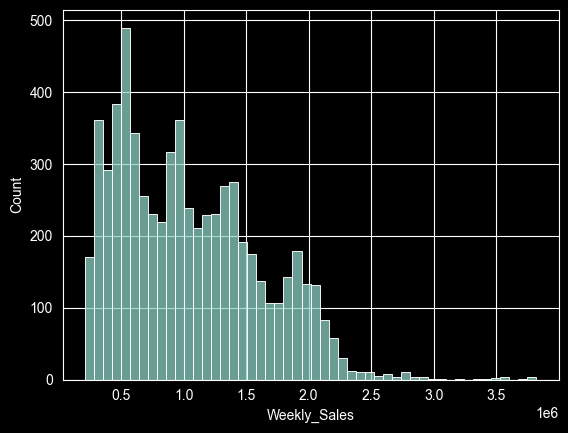

In [4]:
import seaborn as sns
sns.histplot(data['Weekly_Sales'], bins=50)

<Axes: xlabel='Weekly_Sales'>

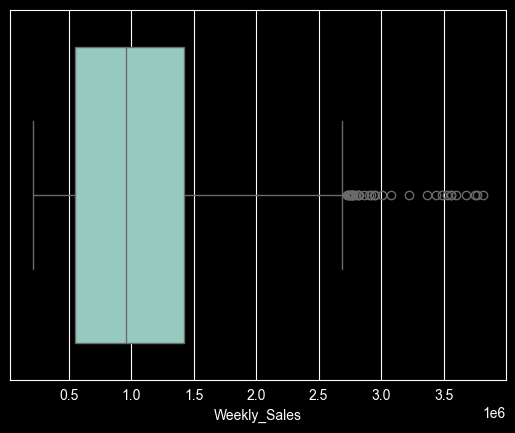

In [5]:
sns.boxplot(x=data['Weekly_Sales'])

The distribution of weekly sales is positively skewed, indicating that most weeks generate moderate revenue while a small number of weeks produce exceptionally high sales. The boxplot reveals several high-value outliers likely corresponding to holiday periods or promotional events. These observations suggest that seasonality and special events significantly influence sales patterns.

In [6]:
df = data.copy()

In [7]:
 df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

<Axes: xlabel='Date'>

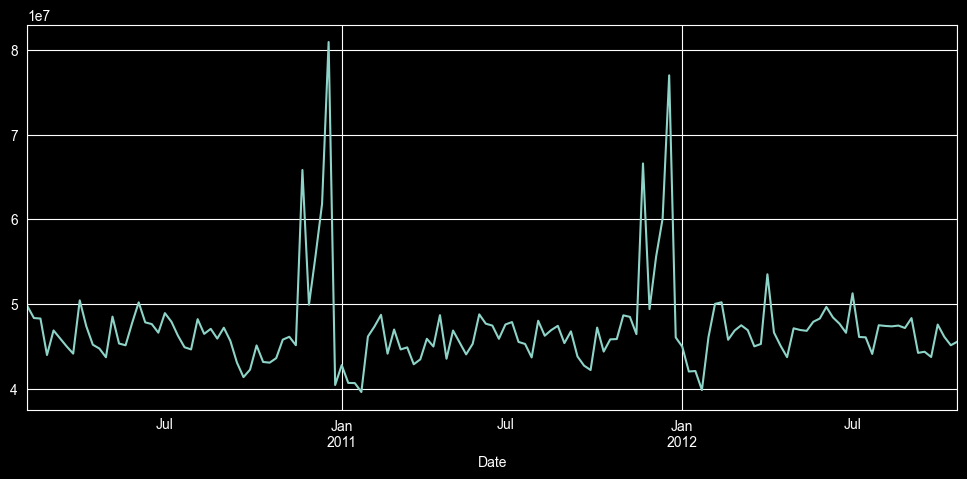

In [8]:
sales_over_time = df.groupby('Date')['Weekly_Sales'].sum()
sales_over_time.plot(figsize=(12,5))

The baseline remains relatively stable throughout the entire period, with minor fluctuations reflecting normal week-to-week variation in consumer behavior.
Two dominant spikes stand out clearly, occurring at roughly the same point each year — almost certainly corresponding to the Christmas/New Year holiday period, confirming strong and repeatable annual seasonality.
Smaller secondary spikes are also visible mid-year, likely tied to other recognized holiday events in the Walmart calendar.
Post-spike drops are equally sharp — sales fall notably right after each peak before gradually recovering to the baseline, the classic post-holiday correction.
No significant upward or downward trend is visible across the full period — the series is essentially stationary in its baseline, meaning what drives variation here is seasonality, not long-term growth.

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

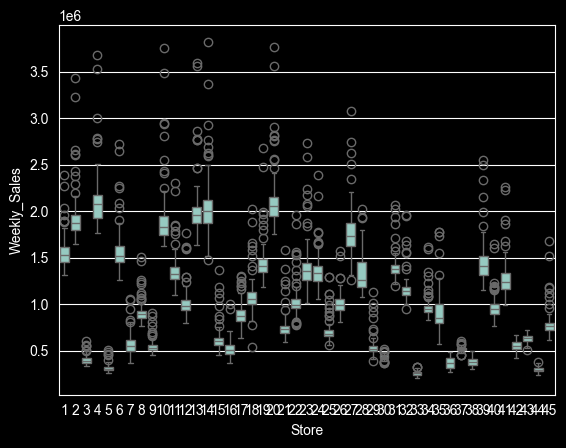

In [9]:
sns.boxplot(x='Store', y='Weekly_Sales', data=data)

The per-store boxplot reveals substantial heterogeneity across the 45 stores, with median weekly sales ranging from under 500K in some stores to over 2M in others. This wide disparity strongly suggests that stores differ in size, location, or customer base, and likely fall into distinct performance tiers. The varying box heights also indicate that some stores exhibit highly volatile sales while others remain relatively stable week to week. This confirms that Store identity will be a critical predictor in any predictive model.

<Axes: >

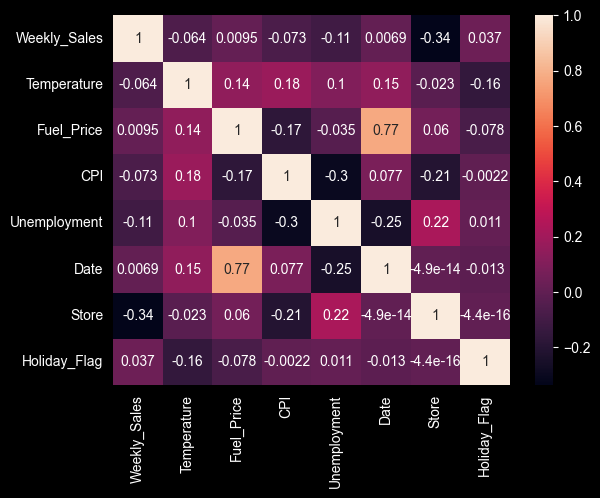

In [10]:
corr = df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Date','Store', 'Holiday_Flag']].corr()
sns.heatmap(corr, annot=True)

Store has the strongest correlation with Weekly_Sales among all features, and it's negative; meaning as store number increases, sales tend to decrease.

Fuel_Price and Date have a very strong positive correlation. It means fuel prices rose consistently over time across the data collection period.

In [11]:
from data_engineering import todate
data1 = todate(data)

In [12]:
data1.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


In [13]:
from data_engineering import encode_store
df_encoded = encode_store(data1)

(6435, 54)


In [14]:
print(df_encoded.head())

        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  \
0 2010-02-05    1643690.90             0        42.31       2.572  211.096358   
1 2010-02-12    1641957.44             1        38.51       2.548  211.242170   
2 2010-02-19    1611968.17             0        39.93       2.514  211.289143   
3 2010-02-26    1409727.59             0        46.63       2.561  211.319643   
4 2010-03-05    1554806.68             0        46.50       2.625  211.350143   

   Unemployment  year  month  week  ...  Store_36  Store_37  Store_38  \
0         8.106  2010      2     5  ...     False     False     False   
1         8.106  2010      2     6  ...     False     False     False   
2         8.106  2010      2     7  ...     False     False     False   
3         8.106  2010      2     8  ...     False     False     False   
4         8.106  2010      3     9  ...     False     False     False   

   Store_39  Store_40  Store_41  Store_42  Store_43  Store_44  Store_45  


In [15]:
import sklearn
from sklearn.feature_selection import mutual_info_regression
from feature_selection import compute_mutual_info
mi_scores = compute_mutual_info(df_encoded)
print(mi_scores)


         Feature  MI_Score
0   Unemployment  0.689168
1            CPI  0.521279
2       Store_33  0.083639
3       Store_30  0.064113
4    Temperature  0.061066
5       Store_44  0.060443
6     Fuel_Price  0.055508
7        Store_5  0.054994
8       Store_37  0.053318
9        Store_3  0.053247
10      Store_43  0.050879
11      Store_38  0.050675
12      Store_20  0.049452
13       Store_4  0.049184
14      Store_45  0.048571
15         month  0.044853
16      Store_10  0.044643
17      Store_21  0.044616
18       Store_2  0.042500
19      Store_32  0.042466
20      Store_13  0.042061
21      Store_36  0.041301
22      Store_14  0.040455
23      Store_34  0.040206
24      Store_25  0.040169
25       Store_8  0.039979
26      Store_31  0.038523
27      Store_42  0.038386
28       Store_9  0.038077
29      Store_29  0.037568
30      Store_26  0.035289
31       Store_6  0.034055
32      Store_27  0.033226
33      Store_19  0.033032
34      Store_16  0.032994
35      Store_17  0.032837
3

In [16]:
from feature_selection import compute_redundancy
redundancy_matrix = compute_redundancy(df_encoded)
print(redundancy_matrix)

              Holiday_Flag  Temperature  Fuel_Price       CPI  Unemployment  \
Holiday_Flag      0.267194     0.041057    0.179990  0.165409      0.000000   
Temperature       0.042197     7.300569    0.559506  0.606148      0.432838   
Fuel_Price        0.175094     0.559075    6.465127  3.060422      0.988091   
CPI               0.163691     0.605967    3.059583  7.020036      3.492276   
Unemployment      0.002476     0.433397    0.984908  3.491836      5.730495   
year              0.000583     0.138020    0.881017  0.860836      1.084517   
month             0.088534     0.713894    1.748670  1.849573      1.362469   
week              0.244444     0.853908    2.918371  2.366402      0.209955   
Store_2           0.017191     0.002314    0.002800  0.018621      0.060648   
Store_3           0.010164     0.008467    0.002045  0.034044      0.079613   
Store_4           0.010774     0.007087    0.014067  0.024505      0.111641   
Store_5           0.011714     0.005690    0.000564 

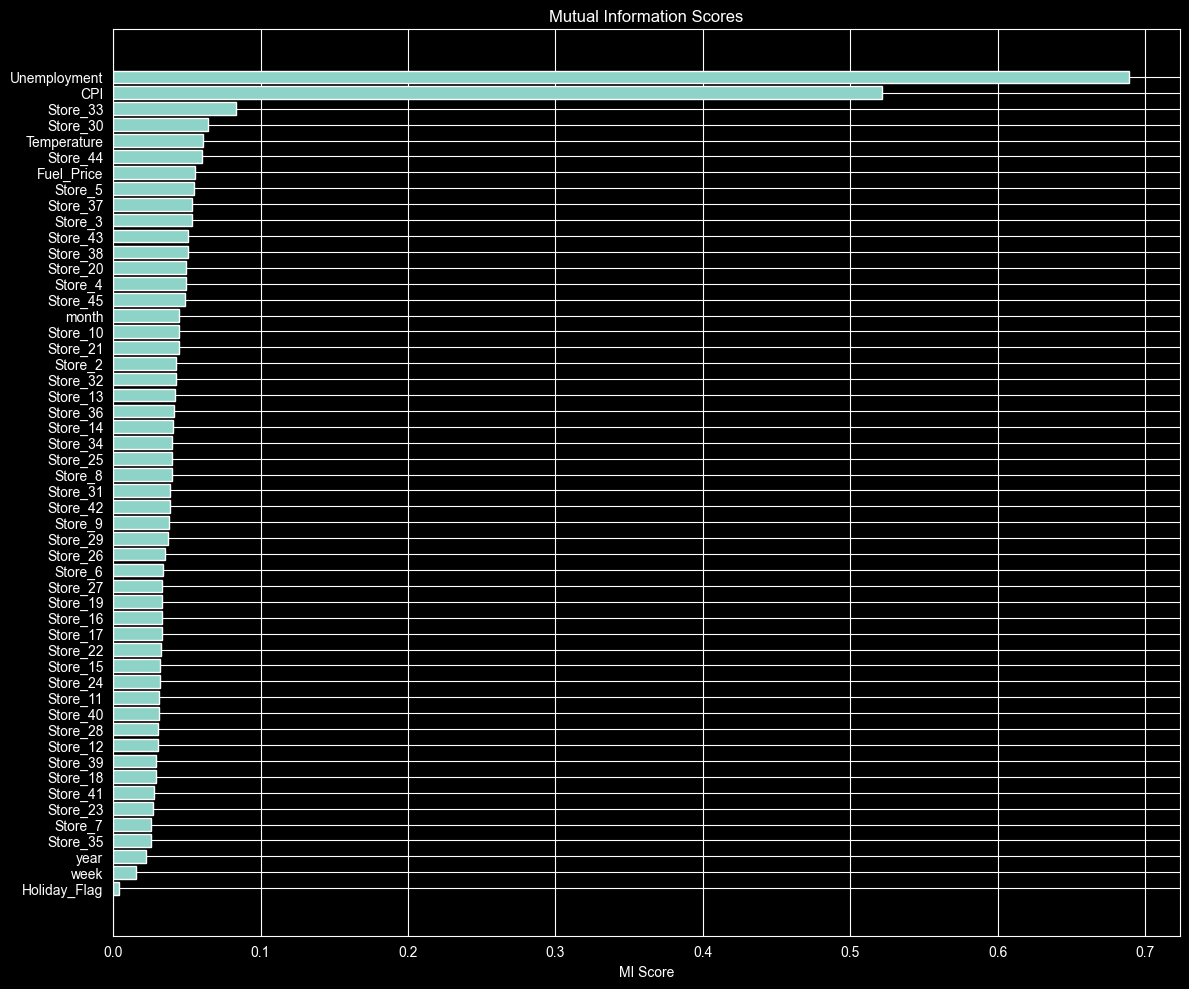

In [17]:
import matplotlib.pyplot as plt

def plot_mi_scores(mi_df):
    plt.figure(figsize=(12, 10))
    plt.barh(mi_df['Feature'], mi_df['MI_Score'])
    plt.xlabel('MI Score')
    plt.title('Mutual Information Scores')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_mi_scores(mi_scores)

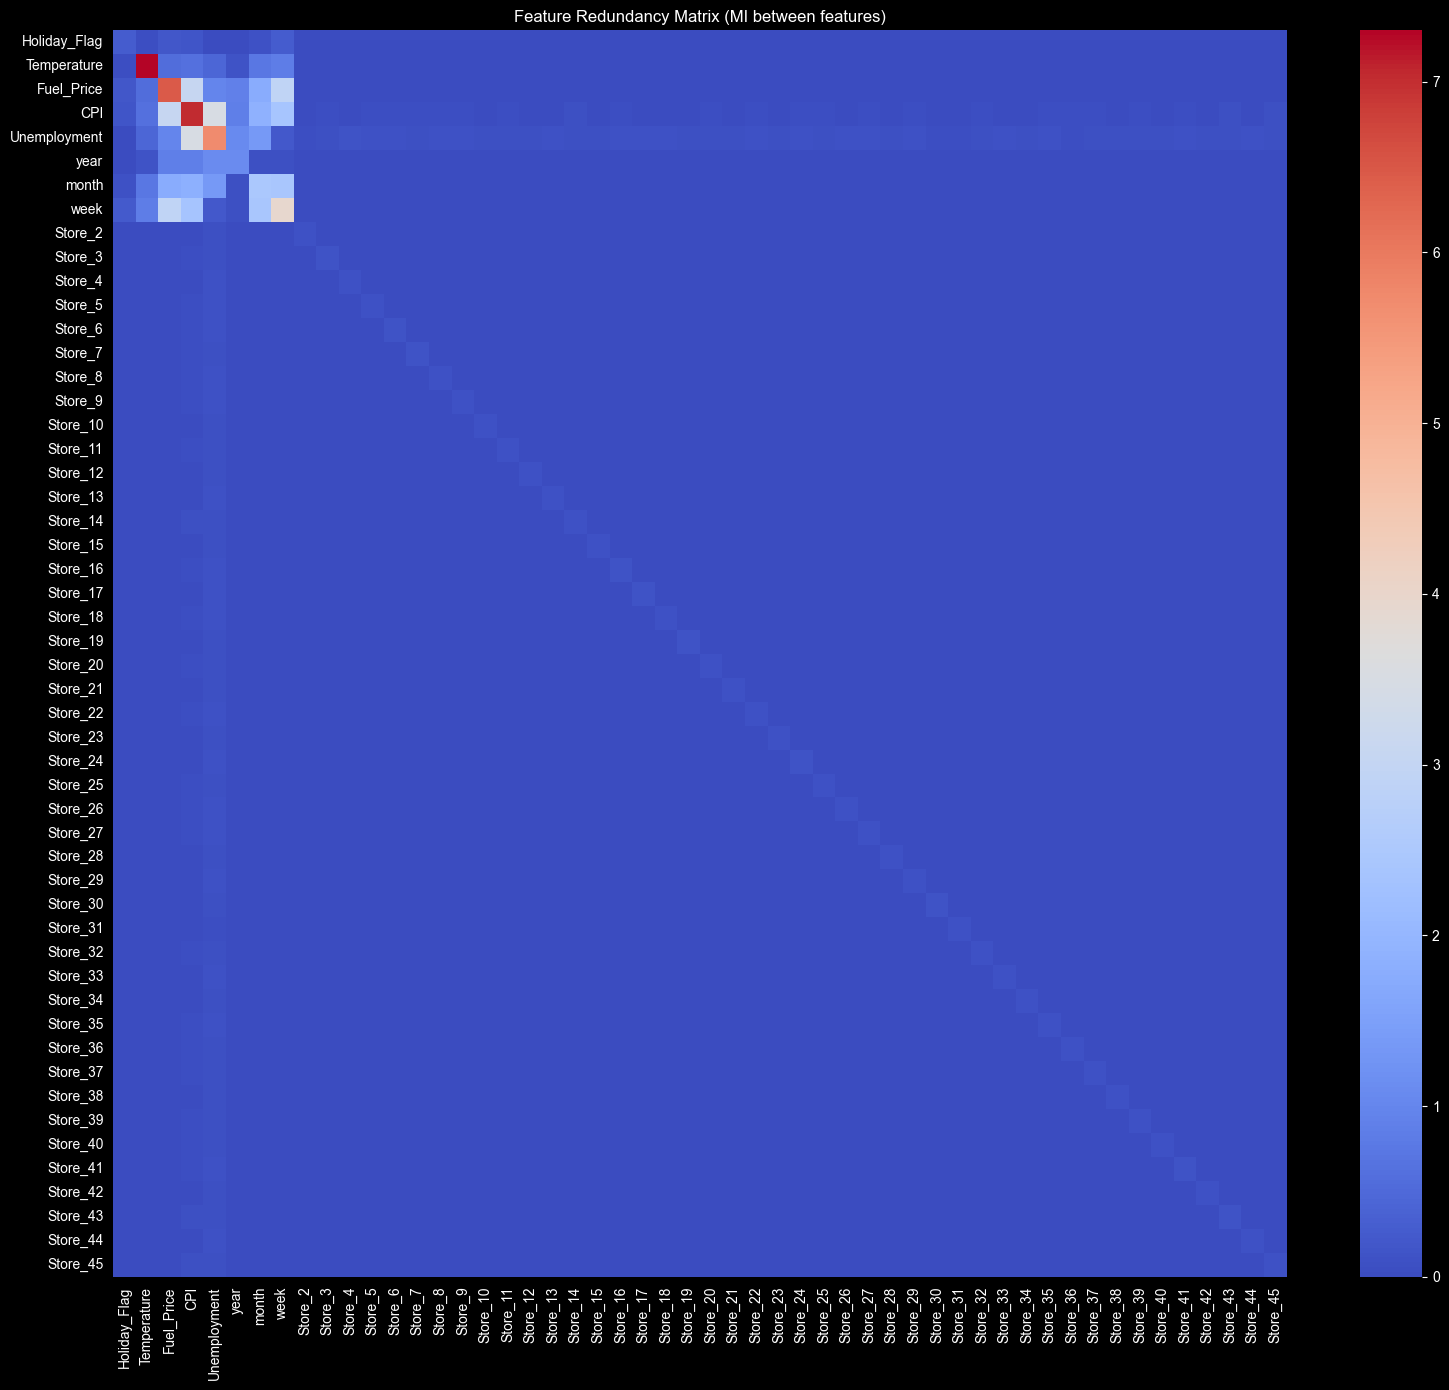

In [18]:
def plot_redundancy(redundancy_matrix):
    plt.figure(figsize=(16, 14))
    sns.heatmap(redundancy_matrix, annot=False, cmap='coolwarm')
    plt.title('Feature Redundancy Matrix (MI between features)')
    plt.tight_layout()
    plt.show()

plot_redundancy(redundancy_matrix)

In [19]:
"""Unemployment and CPI are by far the strongest individual predictors — which is surprising given their weak correlation with Weekly_Sales in the heatmap. This means their relationship with sales is non-linear — correlation missed it but mutual information caught it.
All Store dummies cluster in the middle with similar scores — collectively they carry a lot of signal, and none of them should be dropped individually since they work together as a group.
Fuel_Price scores low but not zero — there's a small amount of useful information in it.
Holiday_Flag is dead last with a near-zero score — It carries almost no useful information about Weekly_Sales on its own.
week and year are also very weak — we will drop them too."""

"Unemployment and CPI are by far the strongest individual predictors — which is surprising given their weak correlation with Weekly_Sales in the heatmap. This means their relationship with sales is non-linear — correlation missed it but mutual information caught it.\nAll Store dummies cluster in the middle with similar scores — collectively they carry a lot of signal, and none of them should be dropped individually since they work together as a group.\nFuel_Price scores low but not zero — there's a small amount of useful information in it.\nHoliday_Flag is dead last with a near-zero score — It carries almost no useful information about Weekly_Sales on its own.\nweek and year are also very weak — we will drop them too."

In [20]:
from feature_selection import select_features
X, y = select_features(df_encoded, mi_scores)
print("X shape:", X.shape)
print(X.columns.tolist())

Dropped features: ['year', 'Holiday_Flag', 'week', 'Fuel_Price']
Remaining features: 48
X shape: (6435, 48)
['Temperature', 'CPI', 'Unemployment', 'month', 'Store_2', 'Store_3', 'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9', 'Store_10', 'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15', 'Store_16', 'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21', 'Store_22', 'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27', 'Store_28', 'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33', 'Store_34', 'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39', 'Store_40', 'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45']


In [21]:
from sklearn.model_selection import train_test_split
from modeling import split_data, scale_features

X_train, X_test, y_train, y_test = split_data(X, y)

X_train shape: (5148, 48)
X_test shape: (1287, 48)
y_train shape: (5148,)
y_test shape: (1287,)


In [22]:
from sklearn.preprocessing import StandardScaler
from modeling import scale_features
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

Scaling done!
X_train mean (sample): {'Temperature': 0.0, 'CPI': 0.0, 'Unemployment': 0.0}
X_train std  (sample): {'Temperature': 1.0001, 'CPI': 1.0001, 'Unemployment': 1.0001}


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compare_models(X_train, y_train, cv=10):
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(),
        'KNN': KNeighborsRegressor(),
        'Random Forest': RandomForestRegressor(random_state=42)
    }

    results = {}
    for name, model in models.items():
        r2_scores  = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
        mse_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
        mae_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')

        results[name] = {
            'mean_r2':   r2_scores.mean(),
            'std_r2':    r2_scores.std(),
            'mean_mse':  (-mse_scores).mean(),
            'mean_mae':  (-mae_scores).mean()
        }
        print(f"{name:25s} → R²: {r2_scores.mean():.4f} ± {r2_scores.std():.4f} | MSE: {(-mse_scores).mean():,.0f} | MAE: {(-mae_scores).mean():,.0f}")

    return results

results = compare_models(X_train_scaled, y_train)

Linear Regression         → R²: 0.9254 ± 0.0122 | MSE: 23,814,267,237 | MAE: 96,489
Ridge Regression          → R²: 0.9254 ± 0.0123 | MSE: 23,816,759,364 | MAE: 96,431
KNN                       → R²: 0.9347 ± 0.0134 | MSE: 20,798,386,595 | MAE: 76,522
Random Forest             → R²: 0.9326 ± 0.0121 | MSE: 21,451,872,948 | MAE: 73,344


All four models perform strongly, with R² scores above 0.92 across the board, meaning each model explains more than 92% of the variance in weekly sales. This is a strong result and validates that our feature selection process was effective — the features we kept genuinely capture the patterns driving sales.

Linear Regression and Ridge Regression are virtually identical in all three metrics, which confirms what we suspected earlier — multicollinearity between CPI and Unemployment is not severe enough to meaningfully hurt linear regression. Ridge's regularization had nothing significant to correct here.

KNN and Random Forest outperform the linear models on MSE and MAE, which makes intuitive sense — both models capture non-linear relationships and local patterns that a linear model simply cannot express. The store-level and seasonal dynamics in this dataset are complex enough that non-linear models pick up additional signal.

Random Forest is the most balanced model overall — it achieves the best MAE, strong MSE, competitive R², and the most stable performance across folds (lowest variance relative to its score). This suggests it generalizes well and isn't overfitting to any particular fold.

KNN performs well but is slightly less stable, reflected in its higher std on R² compared to Random Forest. This means its performance varies more depending on which subset of data it sees, which is a reliability concern in production.

In [34]:
from sklearn.ensemble import RandomForestRegressor

def train_model(X_train, y_train):
    model = RandomForestRegressor(n_estimators=150, random_state=42)
    model.fit(X_train, y_train)
    print("Model trained successfully!")
    return model

model = train_model(X_train_scaled, y_train)

Model trained successfully!


In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"R²   : {r2:.4f}")
    print(f"MSE  : {mse:,.0f}")
    print(f"RMSE : {rmse:,.0f}")
    print(f"MAE  : {mae:,.0f}")

    return y_pred, r2, mse, mae

y_pred, r2, mse, mae = evaluate_model(model, X_test_scaled, y_test)

R²   : 0.9247
MSE  : 24,248,098,094
RMSE : 155,718
MAE  : 77,024


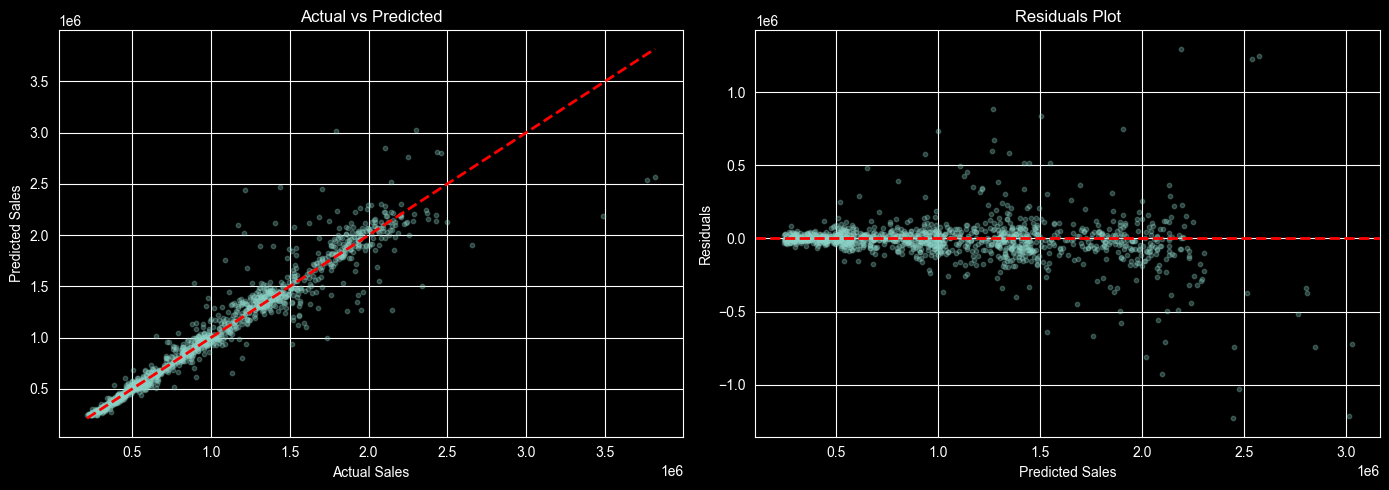

In [36]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1 — Actual vs Predicted scatter
    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
    axes[0].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 color='red', linewidth=2, linestyle='--')
    axes[0].set_xlabel('Actual Sales')
    axes[0].set_ylabel('Predicted Sales')
    axes[0].set_title('Actual vs Predicted')

    # Plot 2 — Residuals
    residuals = y_test - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
    axes[1].set_xlabel('Predicted Sales')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals Plot')

    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred)

In [37]:
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


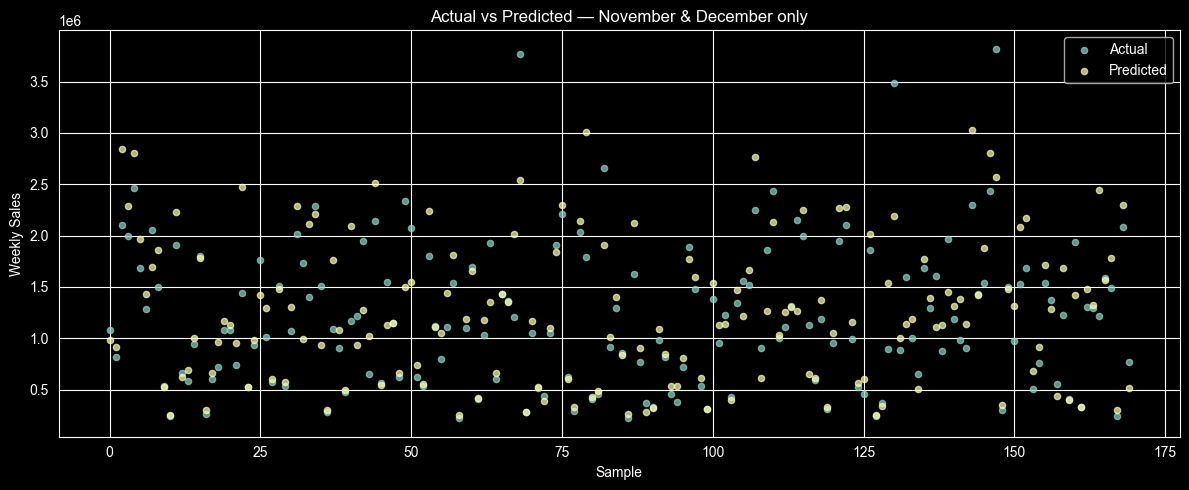

Holiday months MAE: $244,641
Holiday months R² : 0.7038


In [39]:
def plot_holiday_predictions(y_test, y_pred, X_test):
    results_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=y_test.index)

    # Add month back from original df
    results_df['month'] = X_test['month'].values

    # Filter November and December
    holiday_months = results_df[results_df['month'].isin([11, 12])]

    plt.figure(figsize=(12, 5))
    plt.scatter(range(len(holiday_months)), holiday_months['Actual'],
                label='Actual', alpha=0.7, s=20)
    plt.scatter(range(len(holiday_months)), holiday_months['Predicted'],
                label='Predicted', alpha=0.7, s=20)
    plt.title('Actual vs Predicted — November & December only')
    plt.xlabel('Sample')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print error metrics for those months only
    from sklearn.metrics import mean_absolute_error, r2_score
    print("Holiday months MAE:", f"${mean_absolute_error(holiday_months['Actual'], holiday_months['Predicted']):,.0f}")
    print("Holiday months R² :", f"{r2_score(holiday_months['Actual'], holiday_months['Predicted']):.4f}")

plot_holiday_predictions(y_test, y_pred, X_test)